# AVERAGE THE DATA IN THE SAME COORDINATES

In [1]:
import sys
print(sys.executable)

/bin/python


In [2]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib

In [3]:
def plotColsOnMap(cols,df, log_range = False):
    #the index is reset from using lat and lon just in case
    df_reset = df.reset_index()

    #the number of rows varies depending on the number of columns to plot
    rows = (len(cols)//2) + (len(cols)%2==1)

    #a set of subplots is created
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, rows*4), subplot_kw={"projection": ccrs.PlateCarree()})

    #we plot each column
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]#subplot

        #we want to see the coastlines on the globe and only take not null values
        ax.add_feature(cfeature.COASTLINE)
        valid_data = df_reset[df_reset[col].notna()]

        #this sets the logorithmic scale to be exactly like in the paper instead of default
        norm = matplotlib.colors.LogNorm(vmin=1e3, vmax=1e11)
        if(not log_range):
            norm = matplotlib.colors.LogNorm()

        #scatter plot is created
        sc = ax.scatter(
            valid_data["LONGITUDE"],
            valid_data["LATITUDE"],
            c=valid_data[col]*(10**6),
            cmap="viridis",
            s=40,
            transform=ccrs.PlateCarree(),
            norm=norm
        )

        #we want to see the entire globe and not just the values 
        ax.set_xlim(-180,180)
        ax.set_ylim(-90,90)

        plt.colorbar(sc, ax=ax, label="nifH Gene (copies m-3)")
        ax.set_title(col.replace("x106 ",""))

    plt.tight_layout()
    plt.show()

In [4]:
bact_cols=['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

### Required files:
We load the data and save it in a pandas dataframe.
- ***./csv/features/bact_data.csv***

In [5]:
nifh_df = pd.read_csv("./csv/features/bact_data.csv") 
print(nifh_df.columns)
nifh_df.info()

Index(['LATITUDE', 'LONGITUDE', 'Trichodesmium nifH Gene (x106 copies m-3)',
       'UCYN-A nifH Gene (x106 copies m-3)',
       'UCYN-B nifH Gene (x106 copies m-3)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4592 entries, 0 to 4591
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   4592 non-null   float64
 1   LONGITUDE                                  4592 non-null   float64
 2   Trichodesmium nifH Gene (x106 copies m-3)  3487 non-null   float64
 3   UCYN-A nifH Gene (x106 copies m-3)         3700 non-null   float64
 4   UCYN-B nifH Gene (x106 copies m-3)         3115 non-null   float64
dtypes: float64(5)
memory usage: 179.5 KB


### Not all columns have enough data
Obviously we can tell that some columns like Gamma-A have not enough data, so we would rather not use it for our model. 
### There are duplicate coordinates
Also, for each of these types of bacteria there might be duplicate coordinates. In such cases we want to average the data on that coordinate. I have a suspicion that if we just group the main dataframe by coordinates and take mean it can lead to a lot of null values. I will test this theory.

**2 methods for averaging**:
1. simple average after group by
2. separate all columns average and join back together

### Simple average

In [6]:
#this takes an average in a simple way
nifh_simple_avg = nifh_df.groupby(by=['LATITUDE', 'LONGITUDE']).mean().reset_index()
print(nifh_simple_avg.columns)
nifh_simple_avg.info()

Index(['LATITUDE', 'LONGITUDE', 'Trichodesmium nifH Gene (x106 copies m-3)',
       'UCYN-A nifH Gene (x106 copies m-3)',
       'UCYN-B nifH Gene (x106 copies m-3)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039 entries, 0 to 1038
Data columns (total 5 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   1039 non-null   float64
 1   LONGITUDE                                  1039 non-null   float64
 2   Trichodesmium nifH Gene (x106 copies m-3)  827 non-null    float64
 3   UCYN-A nifH Gene (x106 copies m-3)         864 non-null    float64
 4   UCYN-B nifH Gene (x106 copies m-3)         507 non-null    float64
dtypes: float64(5)
memory usage: 40.7 KB


In [7]:
nifh_simple_avg.describe()

,LATITUDE,LONGITUDE,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
count,1039.000000,1039.000000,8.270000e+02,8.640000e+02,507.000000
mean,20.785371,-5.630414,5.651634e+04,3.653867e+03,256.515542
std,26.149473,123.860269,1.309133e+06,8.068031e+04,3905.723920
min,-76.000000,-180.000000,0.000000e+00,0.000000e+00,0.000000
25%,9.000000,-124.500000,1.760100e+00,2.665000e-01,0.000000
50%,25.000000,-32.000000,3.636667e+01,5.250000e+00,0.438500
75%,35.000000,135.000000,2.344230e+02,9.662500e+01,9.027183
max,120.000000,187.000000,3.630781e+07,2.360150e+06,87605.116104


In [8]:
nifh_simple_avg.to_csv("./csv/features/bact_data_avg2.csv", index=False)

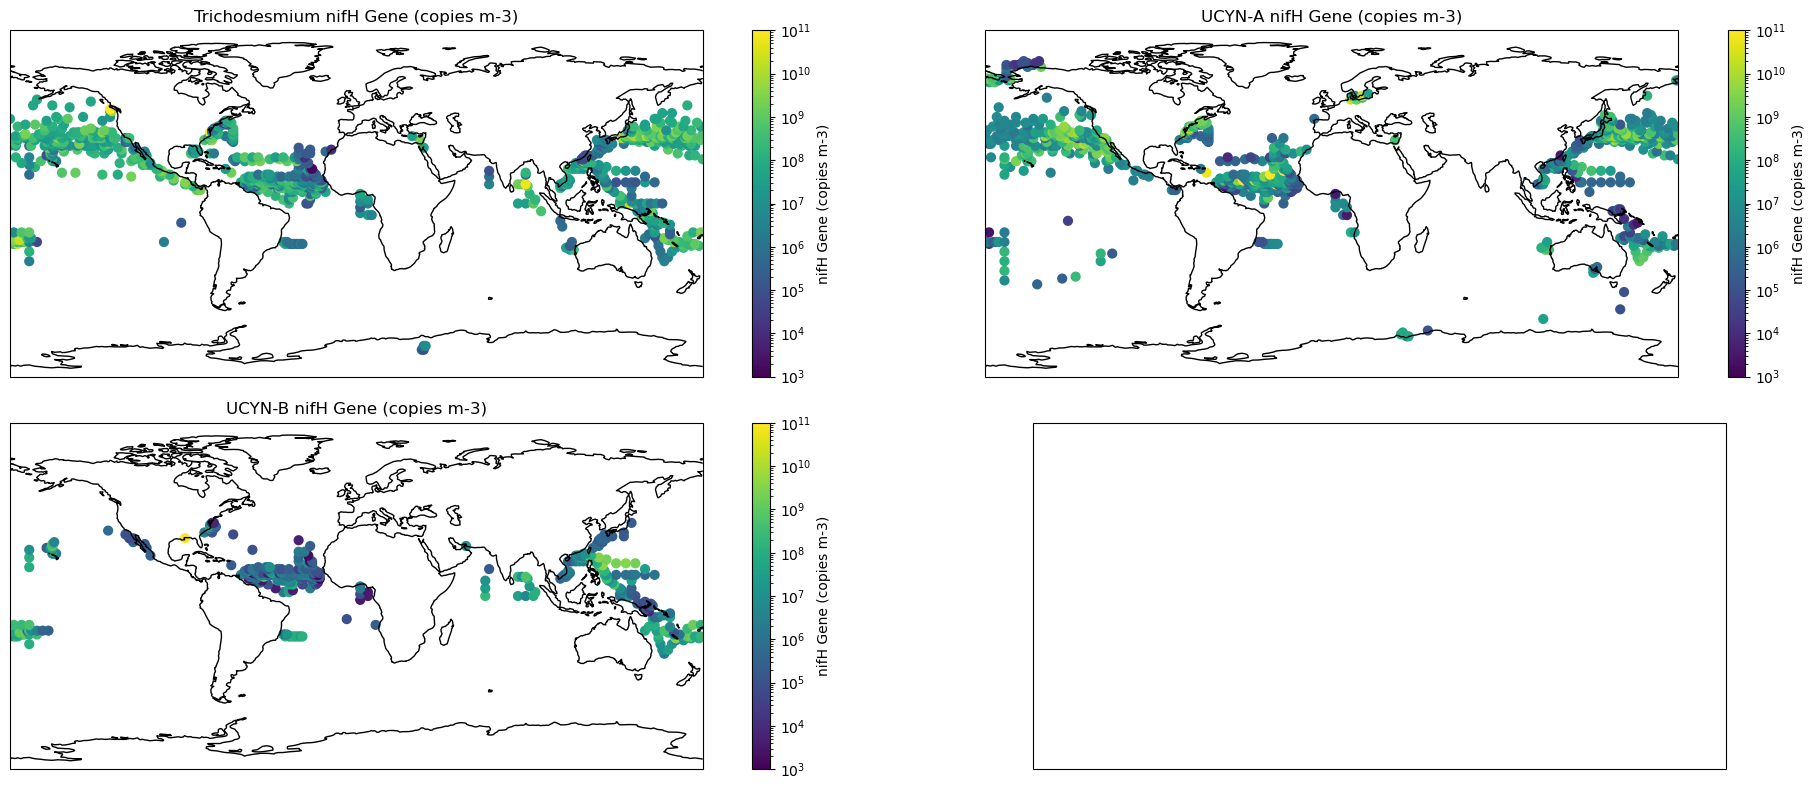

In [9]:
plotColsOnMap(bact_cols, nifh_simple_avg, True)

### Complicated average
We store the list of columns that we intend to learn from and create the model. I separated the data columns and the coordinates.

In [10]:
data_cols = ['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']
cor_cols = ['LATITUDE', 'LONGITUDE']

In [11]:
frames = []

for col in data_cols:
    #we only take a look at specific column from the dataset
    selected_data = nifh_df[cor_cols+[col]]

    #we only want to average the not na values in order not to produce nulls
    notna_mask = selected_data[col].notna()
    selected_data_notna = selected_data[notna_mask]
    print("{0}: not null values: {1}, shape: {2}".format(col, notna_mask.sum(), selected_data_notna.shape))#we can verify that we have only not null values

    #now we can average based on coordinates
    selected_data_avg = selected_data_notna.groupby(by=['LATITUDE', 'LONGITUDE']).mean()
    print("{0}: shape after averaging: {1}\n".format(col, selected_data_avg.shape))

    #we add the modified dataframe to the list
    frames.append(selected_data_avg)


Trichodesmium nifH Gene (x106 copies m-3): not null values: 3487, shape: (3487, 3)
Trichodesmium nifH Gene (x106 copies m-3): shape after averaging: (827, 1)

UCYN-A nifH Gene (x106 copies m-3): not null values: 3700, shape: (3700, 3)
UCYN-A nifH Gene (x106 copies m-3): shape after averaging: (864, 1)

UCYN-B nifH Gene (x106 copies m-3): not null values: 3115, shape: (3115, 3)
UCYN-B nifH Gene (x106 copies m-3): shape after averaging: (507, 1)



In [12]:
#concatenate based on index(coordinates)
nifh_avg = pd.concat(frames, axis=1)

nifh_avg.head()

Trichodesmium nifH Gene (x106 copies m-3)  \
LATITUDE LONGITUDE                                              
-76.0    34.0                                        0.329000   
         35.0                                        0.057000   
-75.0    35.0                                        0.103500   
-74.0    35.0                                        1.635286   
         36.0                                        7.797333   

                    UCYN-A nifH Gene (x106 copies m-3)  \
LATITUDE LONGITUDE                                       
-76.0    34.0                                      NaN   
         35.0                                      NaN   
-75.0    35.0                                      NaN   
-74.0    35.0                                      NaN   
         36.0                                      NaN   

                    UCYN-B nifH Gene (x106 copies m-3)  
LATITUDE LONGITUDE                                      
-76.0    34.0                                      NaN  
         35.0                                      NaN  
-75.0    35.0                                      NaN  
-74.0    35.0                                      NaN  
         36.0                                      NaN

In [13]:
nifh_avg.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1039 entries, (np.float64(-76.0), np.float64(34.0)) to (np.float64(30.0), np.float64(-89.0))
Data columns (total 3 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Trichodesmium nifH Gene (x106 copies m-3)  827 non-null    float64
 1   UCYN-A nifH Gene (x106 copies m-3)         864 non-null    float64
 2   UCYN-B nifH Gene (x106 copies m-3)         507 non-null    float64
dtypes: float64(3)
memory usage: 42.8 KB


In [14]:
nifh_avg.describe()

,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
count,8.270000e+02,8.640000e+02,507.000000
mean,5.651634e+04,3.653867e+03,256.515542
std,1.309133e+06,8.068031e+04,3905.723920
min,0.000000e+00,0.000000e+00,0.000000
25%,1.760100e+00,2.665000e-01,0.000000
50%,3.636667e+01,5.250000e+00,0.438500
75%,2.344230e+02,9.662500e+01,9.027183
max,3.630781e+07,2.360150e+06,87605.116104


As we can see the results are exactly the same so a simpler one line method can be used to produce the same result